# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data/bike_share_201402_trip_data.csv')

How many observations are there?

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144015 entries, 0 to 144014
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Trip ID            144015 non-null  int64 
 1   Duration           144015 non-null  int64 
 2   Start Date         144015 non-null  object
 3   Start Station      144015 non-null  object
 4   Start Terminal     144015 non-null  int64 
 5   End Date           144015 non-null  object
 6   End Station        144015 non-null  object
 7   End Terminal       144015 non-null  int64 
 8   Bike #             144015 non-null  int64 
 9   Subscription Type  144015 non-null  object
 10  Zip Code           137885 non-null  object
dtypes: int64(5), object(6)
memory usage: 12.1+ MB


In [6]:
df.head

<bound method NDFrame.head of         Trip ID  Duration       Start Date                      Start Station  \
0          4576        63  8/29/2013 14:13           South Van Ness at Market   
1          4607        70  8/29/2013 14:42                 San Jose City Hall   
2          4130        71  8/29/2013 10:16            Mountain View City Hall   
3          4251        77  8/29/2013 11:29                 San Jose City Hall   
4          4299        83  8/29/2013 12:02           South Van Ness at Market   
...         ...       ...              ...                                ...   
144010   198771       385  2/28/2014 22:15                 Powell Street BART   
144011   198772       145  2/28/2014 22:38           Commercial at Montgomery   
144012   198773       677  2/28/2014 22:45             Embarcadero at Sansome   
144013   198774     64128  2/28/2014 23:01  Civic Center BART (7th at Market)   
144014   198775       570  2/28/2014 23:20                  2nd at South Park  

Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [11]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_', regex=False)
      .str.replace('#', 'num', regex=False)
) 

In [13]:
# Quick sanity
print("Columns:", list(df.columns))
df.head()

Columns: ['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal', 'end_date', 'end_station', 'end_terminal', 'bike_num', 'subscription_type', 'zip_code']


,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


How many types of subscription options are there? What are the different subscription types?

In [14]:
# === 1. How many types of subscription options and what are they? ===
print("\n1) Subscription types (unique values):")
sub_types = df['subscription_type'].astype(str).str.strip()  # normalize whitespace, ensure string
unique_types = sub_types.unique()
print("Number of types:", len(unique_types))
print("Types:", list(unique_types))


1) Subscription types (unique values):
Number of types: 2
Types: ['Subscriber', 'Customer']


What is the frequency of each subscription option?

In [15]:
# === 2. Frequency of each subscription option ===
print("\n2) Frequency of each subscription option:")
freq_sub = sub_types.value_counts(dropna=False)
print(freq_sub)


2) Frequency of each subscription option:
subscription_type
Subscriber    113647
Customer       30368
Name: count, dtype: int64


Please plot the frequency of each subscription option with a pie chart:

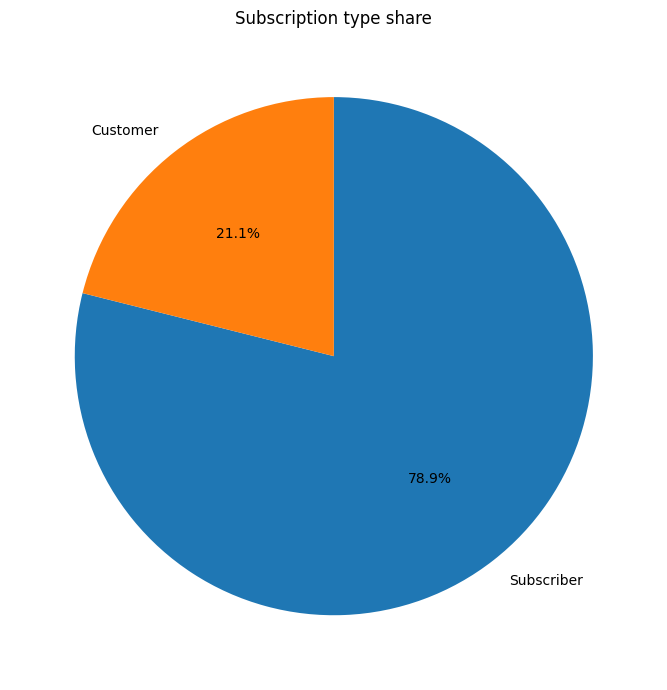

In [16]:
# === 3. Pie chart of subscription option frequency ===
plt.figure(figsize=(7,7))
freq_sub.plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Subscription type share")
plt.ylabel("")  # remove y-label
plt.tight_layout()
plt.show()

Please plot the frequency of each subscription option with a bar chart:

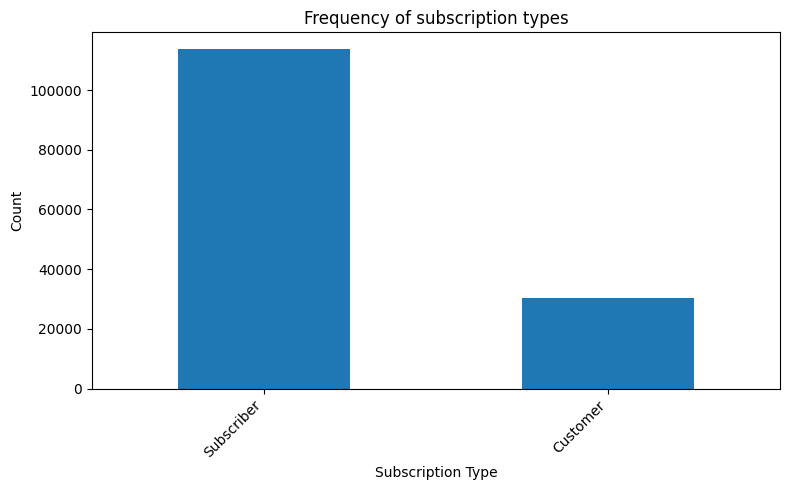

In [17]:
# === 4. Bar chart of subscription option frequency ===
plt.figure(figsize=(8,5))
freq_sub.plot.bar(color='tab:blue')
plt.title("Frequency of subscription types")
plt.xlabel("Subscription Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Have a look at the start_station column: Which 10 stations occur most frequently?

In [22]:
# === 5. Top 10 start stations ===
TOP_N = 10
print("\n5) Top {} start_station values:".format(TOP_N))
top_start = df['start_station'].astype(str).str.strip().value_counts().head(TOP_N)
print(top_start)


5) Top 10 start_station values:
start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64


Now look at the end_station column: Which 10 stations occur the least often?

In [24]:
# === 6. Bottom 10 end stations (least frequent) ===
print("\n6) Bottom {} end_station values (least frequent):".format(TOP_N))
# we want smallest counts; value_counts sorts desc, so use nsmallest
end_counts = df['end_station'].astype(str).str.strip().value_counts()
bottom_end = end_counts.nsmallest(TOP_N)
print(bottom_end)


6) Bottom 10 end_station values (least frequent):
end_station
Mezes Park                            5
San Jose Government Center           23
Broadway at Main                     56
Franklin at Maple                    93
San Antonio Shopping Center          93
San Mateo County Center             106
Redwood City Public Library         117
Castro Street and El Camino Real    129
Redwood City Medical Center         178
Broadway St at Battery St           205
Name: count, dtype: int64


Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [25]:
# === 7. Crosstab: start_station by subscription_type with margins ===
print("\n7) Crosstab of start_station vs subscription_type (with margins):")
ct = pd.crosstab(df['start_station'].astype(str).str.strip(),
                 df['subscription_type'].astype(str).str.strip(),
                 margins=True)
print(ct.head(20))   # show first 20 rows; you can inspect ct fully in notebook


7) Crosstab of start_station vs subscription_type (with margins):
subscription_type                  Customer  Subscriber   All
start_station                                                
2nd at Folsom                           427        3349  3776
2nd at South Park                       535        3923  4458
2nd at Townsend                         882        4105  4987
5th at Howard                           606        2029  2635
Adobe on Almaden                         75         260   335
Arena Green / SAP Center                 82         257   339
Beale at Market                         457        2600  3057
Broadway St at Battery St                20         181   201
Broadway at Main                         14          31    45
California Ave Caltrain Station         161         136   297
Castro Street and El Camino Real         35          97   132
Civic Center BART (7th at Market)       668        2406  3074
Clay at Battery                         563        1856  2419
Com

Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

In [26]:
# === 8. Duration unit, shortest trip and how many ===
print("\n8) Duration column analysis:")
print("dtype:", df['duration'].dtype)
# Many bike datasets use seconds; we will check typical values
duration = pd.to_numeric(df['duration'], errors='coerce')
print("min:", duration.min(), "max:", duration.max(), "median:", duration.median())
shortest = int(duration.min())
n_shortest = int((duration == shortest).sum())
print(f"Shortest trip value: {shortest}; count={n_shortest}")


8) Duration column analysis:
dtype: int64
min: 60 max: 722236 median: 531.0
Shortest trip value: 60; count=17


What do you think is going on with the short trips?

In [28]:
# == 9. What might be going on with very short trips? ===
print("\n9) Hypothesis on short trips:")
print("- If duration is in seconds, a value like 60-120 seconds means 1-2 minutes (possible quick hop).")
print("- Very short durations (e.g., 1-2 seconds) may indicate data errors, cancelled trips, or logging artifacts.")
# Give examples of very short trips
very_short = df[duration <= 5]   # <=5 seconds
print("Number of trips with duration <= 5:", len(very_short))
if len(very_short) > 0:
    print("Sample very short rows:\n", very_short.head(5))


9) Hypothesis on short trips:
- If duration is in seconds, a value like 60-120 seconds means 1-2 minutes (possible quick hop).
- Very short durations (e.g., 1-2 seconds) may indicate data errors, cancelled trips, or logging artifacts.
Number of trips with duration <= 5: 0


What is the longest trip?

In [29]:
# === 10. Longest trip ===
longest = int(duration.max())
print("\n10) Longest trip value:", longest)


10) Longest trip value: 722236


How would you define a "long" trip? How many trips are "long" according to your definition?

In [ ]:
# === 11. Define "long" trip and count ===
# We'll define "long" as duration greater than mean + 3*std (outlier approach) OR > 2 hours (7200s) - show both options.
mean_d = duration.mean()
std_d = duration.std()
threshold_stat = mean_d + 3*std_d
threshold_hours = 2*3600  # seconds
n_long_stat = int((duration > threshold_stat).sum())
n_long_hours = int((duration > threshold_hours).sum())

print("\n11) Defining long trips:")
print(f"- Threshold (mean + 3*std): {threshold_stat:.1f} seconds -> count = {n_long_stat}")
print(f"- Threshold (>= 2 hours = {threshold_hours} s): count = {n_long_hours}")


12) Interpretation of long durations:
- Very long durations can be real (lost bike, theft, user forgot to end trip), or logging issues.
- Look at sample of longest trips to inspect start/end stations, subscription_type, and zip_code to guess reasons.
        trip_id  duration                          start_station  \
80510    111309    722236                 University and Emerson   
93400    129504    619322      San Jose Diridon Caltrain Station   
20535     32121    597517        California Ave Caltrain Station   
119830   166010    586356           San Antonio Caltrain Station   
43549     62246    429384                       Davis at Jackson   
24068     36617    329456                          Park at Olive   
12725     21760    309479                 SJSU 4th at San Carlos   
108144   150269    303271      Civic Center BART (7th at Market)   
100174   138946    296045  Rengstorff Avenue / California Street   
80086    110706    280439                        Post at Kearney   


Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

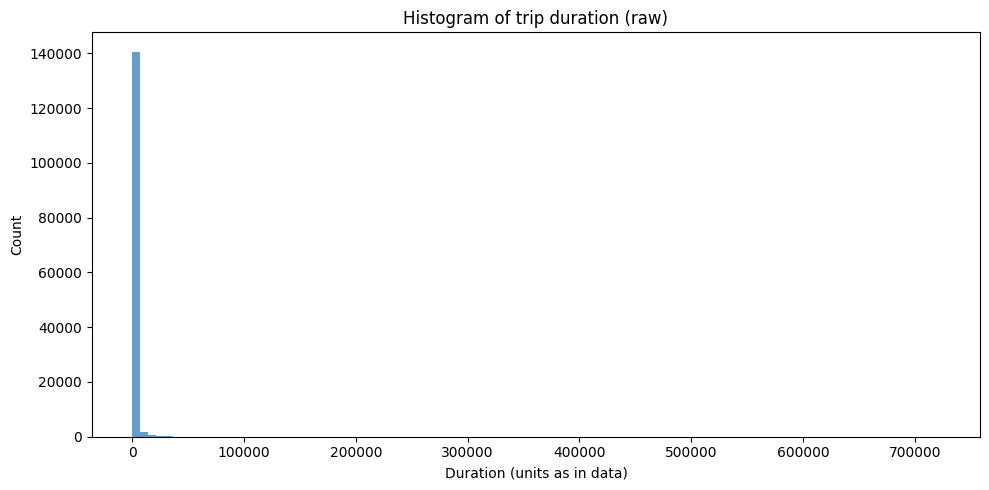

In [ ]:
# === 12. Do long durations seem reasonable? ===
print("\n12) Interpretation of long durations:")
print("- Very long durations can be real (lost bike, theft, user forgot to end trip), or logging issues.")
print("- Look at sample of longest trips to inspect start/end stations, subscription_type, and zip_code to guess reasons.")
long_samples = df.loc[duration.sort_values(ascending=False).index].head(10)
print(long_samples[['trip_id','duration','start_station','end_station','subscription_type','zip_code']].head(10))


Plot the duration column.

In [42]:
# Ensure duration is numeric first (recommended)
df['duration_num'] = pd.to_numeric(df['duration'], errors='coerce')

# Ensure start_station is a clean string (avoids "float object has no attribute 'strip'")
df['start_station_clean'] = df['start_station'].astype(str).str.strip()

# Now compute median duration per station robustly
med_by_station = (
    df.groupby('start_station_clean')['duration_num']
      .median()
      .dropna()
)

med_top10 = med_by_station.sort_values(ascending=False).head(10)

print("Top 10 stations by median duration (descending):")
print(med_top10)


Top 10 stations by median duration (descending):
start_station_clean
University and Emerson                   2498.5
Park at Olive                            1049.0
San Jose Government Center               1007.0
California Ave Caltrain Station           997.0
Embarcadero at Sansome                    772.0
Rengstorff Avenue / California Street     742.0
Embarcadero at Vallejo                    701.0
Washington at Kearney                     681.5
Japantown                                 673.5
San Francisco City Hall                   671.0
Name: duration_num, dtype: float64


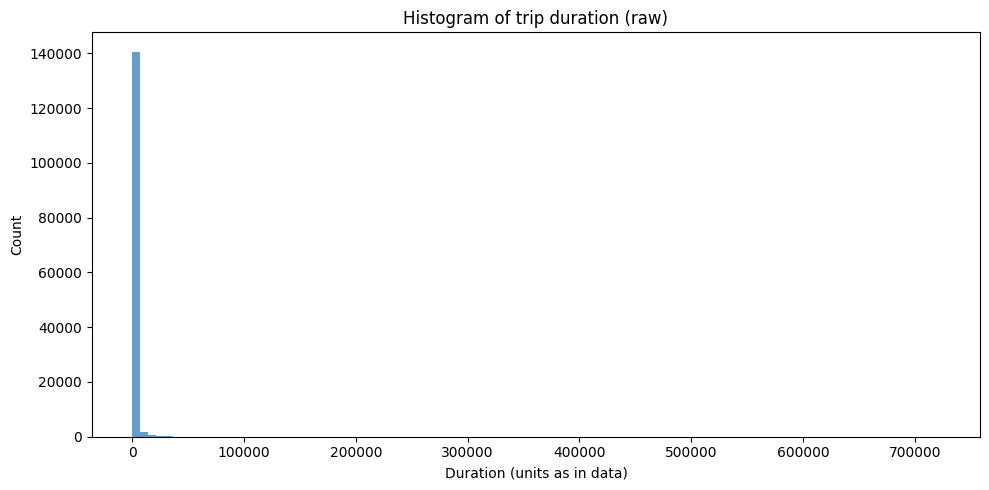

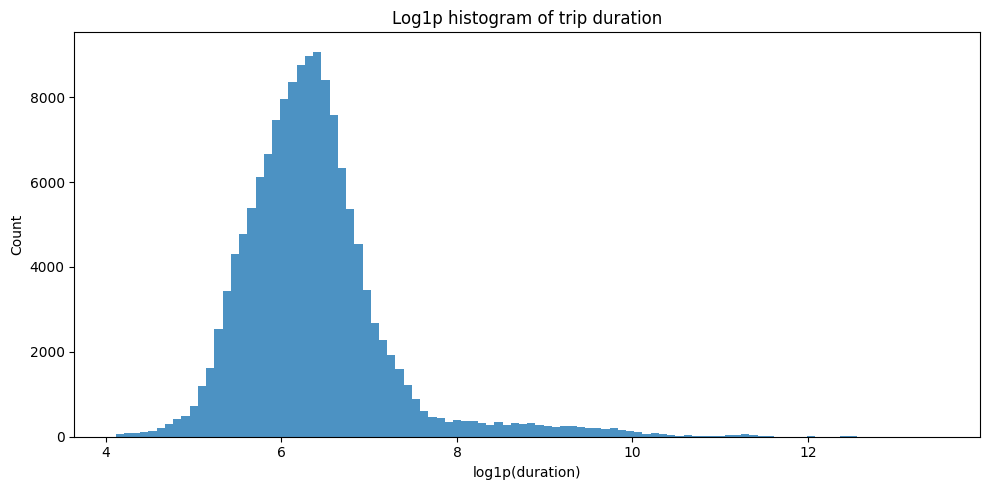

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# === 13. Plot the duration column (histogram) ===
plt.figure(figsize=(10,5))
plt.hist(duration.dropna(), bins=100, alpha=0.7)
plt.title("Histogram of trip duration (raw)")
plt.xlabel("Duration (units as in data)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# log-histogram
plt.figure(figsize=(10,5))
plt.hist(np.log1p(duration.dropna()), bins=100, alpha=0.8)
plt.title("Log1p histogram of trip duration")
plt.xlabel("log1p(duration)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


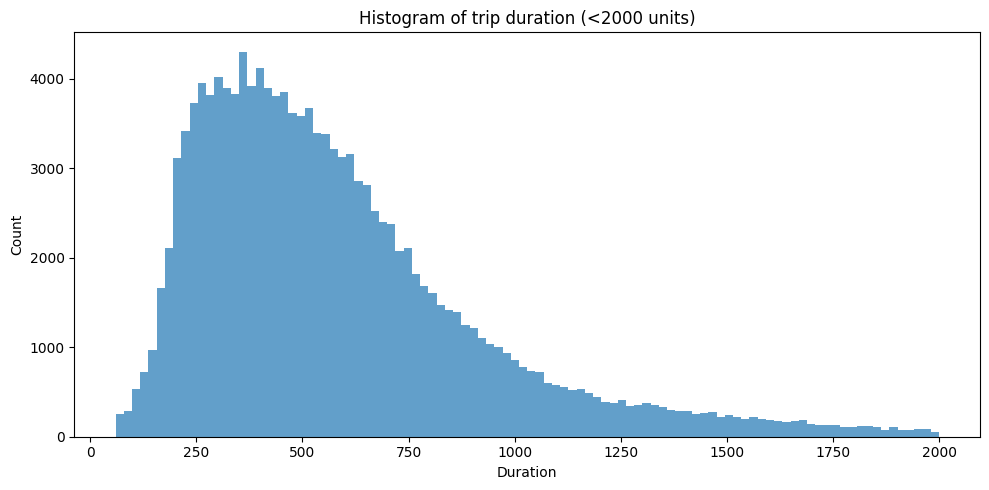

In [ ]:
# Limit the x-axis to a meaningful range
# If 99% < 2000:
plt.figure(figsize=(10,5))
plt.hist(duration[duration < 2000], bins=100, alpha=0.7)
plt.title("Histogram of trip duration (<2000 units)")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


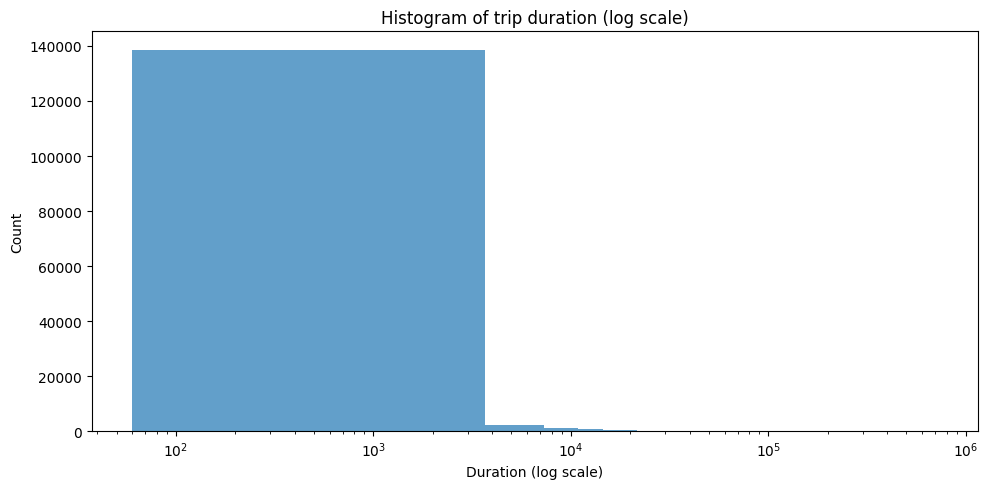

In [ ]:
# Directly visible how skewed the distribution is:
plt.figure(figsize=(10,5))
plt.hist(duration.dropna(), bins=200, alpha=0.7)
plt.xscale("log")
plt.title("Histogram of trip duration (log scale)")
plt.xlabel("Duration (log scale)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


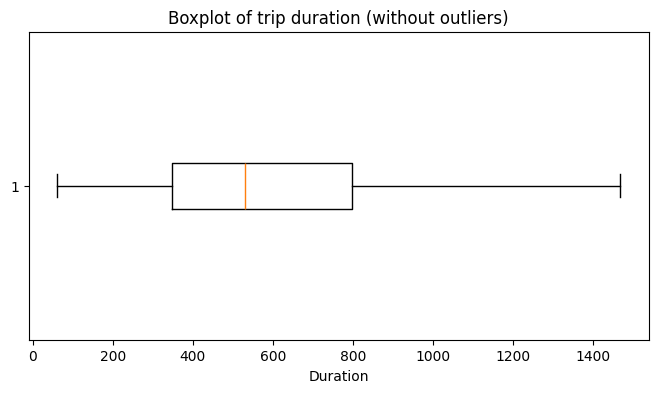

In [48]:
# Box plot for quick outlier checking:
plt.figure(figsize=(8,4))
plt.boxplot(duration.dropna(), vert=False, showfliers=False)
plt.title("Boxplot of trip duration (without outliers)")
plt.xlabel("Duration")
plt.show()


Does this plot give any insights?


14) Example subsections & plots:


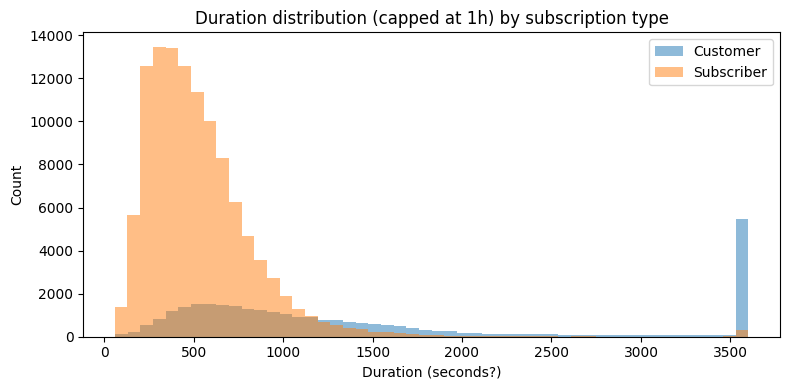

In [38]:
# === 14. Subsections for more insights ===
print("\n14) Example subsections & plots:")
# a) distribution for subscribers vs customers (if these values exist)
if 'Subscriber' in df['subscription_type'].values or 'Subscriber' in df['subscription_type'].str.title().values:
    grp = df.copy()
    grp['subscription_type_norm'] = grp['subscription_type'].astype(str).str.strip().str.title()
    plt.figure(figsize=(8,4))
    for key, subset in grp.groupby('subscription_type_norm'):
        plt.hist(subset['duration'].astype(float).clip(upper=3600), bins=50, alpha=0.5, label=key)  # limit to 1h for clarity
    plt.legend()
    plt.title("Duration distribution (capped at 1h) by subscription type")
    plt.xlabel("Duration (seconds?)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

Select subsections of the data to make plots that provide more insights.

In [39]:
# b) top 10 start stations durations median
med_by_station = df.groupby('start_station')['duration'].agg(lambda x: pd.to_numeric(x, errors='coerce').median()).dropna()
med_top10 = med_by_station.sort_values(ascending=False).head(10)
print("Top 10 stations by median duration (descending):")
print(med_top10)

Top 10 stations by median duration (descending):
start_station
University and Emerson                   2498.5
Park at Olive                            1049.0
San Jose Government Center               1007.0
California Ave Caltrain Station           997.0
Embarcadero at Sansome                    772.0
Rengstorff Avenue / California Street     742.0
Embarcadero at Vallejo                    701.0
Washington at Kearney                     681.5
Japantown                                 673.5
San Francisco City Hall                   671.0
Name: duration, dtype: float64


The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [40]:
# === 15. Normalize station names to lowercase and underscores (no for-loop) ===
# We'll operate vectorized: strip, lowercase, replace spaces & other chars:
def normalize_station_series(s):
    # convert to string, strip, lower, replace non-alphanum groups with underscore, collapse underscores
    out = s.astype(str).str.strip().str.lower()
    out = out.str.replace(r'[^0-9a-z]+', '_', regex=True)  # any non-alnum -> _
    out = out.str.replace(r'_+', '_', regex=True)           # collapse multiple underscores
    out = out.str.strip('_')                               # remove leading/trailing _
    return out

df['start_station_norm'] = normalize_station_series(df['start_station'])
df['end_station_norm']   = normalize_station_series(df['end_station'])
print("\n15) Example normalized station names (sample):")
print(df[['start_station','start_station_norm']].head(10))


15) Example normalized station names (sample):
              start_station        start_station_norm
0  South Van Ness at Market  south_van_ness_at_market
1        San Jose City Hall        san_jose_city_hall
2   Mountain View City Hall   mountain_view_city_hall
3        San Jose City Hall        san_jose_city_hall
4  South Van Ness at Market  south_van_ness_at_market
5       Golden Gate at Polk       golden_gate_at_polk
6    Santa Clara at Almaden    santa_clara_at_almaden
7       San Salvador at 1st       san_salvador_at_1st
8  South Van Ness at Market  south_van_ness_at_market
9        San Jose City Hall        san_jose_city_hall


Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 


16) Timebox: Set a timer for 15 minutes and explore - suggestions:
- Look at duration by hour of day: parse start_date to datetime, extract hour and plot average duration and counts.
- Examine trip counts per day, per month to see seasonality.
- Inspect suspicious users / bikes with many long trips.
- Explore station pairs (start->end) most frequent.


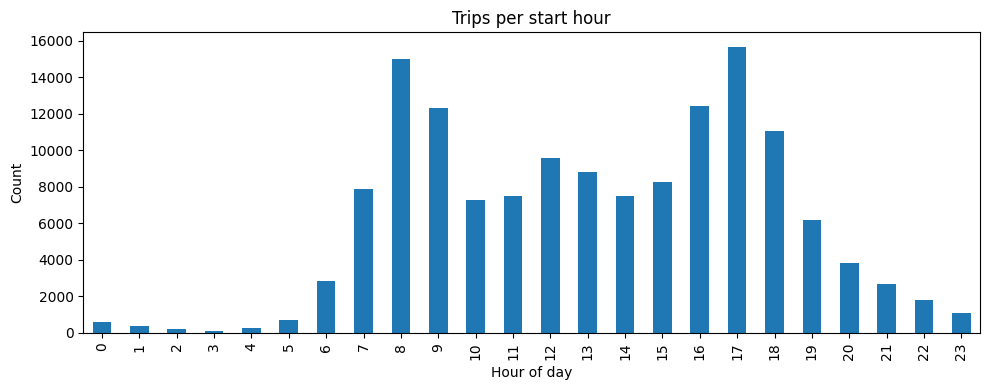

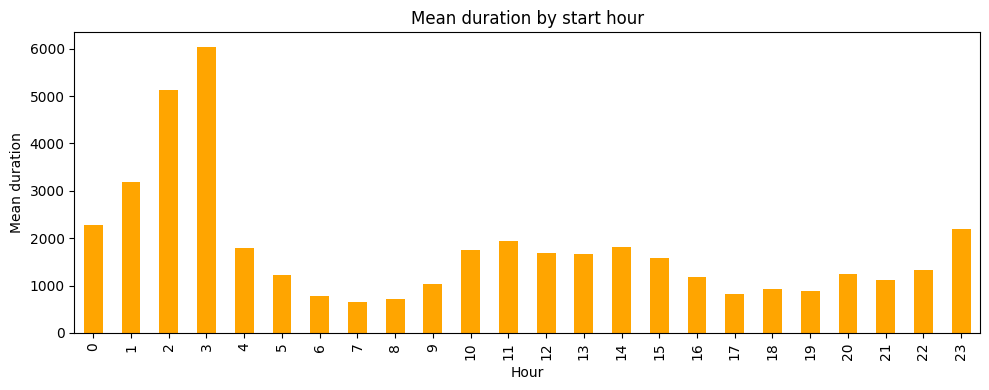


You can continue exploring—timebox 15 minutes and try any hypothesis above.


In [37]:
# === 16. Timebox instruction ===
print("\n16) Timebox: Set a timer for 15 minutes and explore - suggestions:")
print("- Look at duration by hour of day: parse start_date to datetime, extract hour and plot average duration and counts.")
print("- Examine trip counts per day, per month to see seasonality.")
print("- Inspect suspicious users / bikes with many long trips.")
print("- Explore station pairs (start->end) most frequent.")

# Example: duration by hour (quick code snippet)
df['start_date_parsed'] = pd.to_datetime(df['start_date'], errors='coerce')
df['start_hour'] = df['start_date_parsed'].dt.hour
hour_counts = df.groupby('start_hour').size()
hour_mean_dur = df.groupby('start_hour')['duration'].agg(lambda x: pd.to_numeric(x, errors='coerce').mean())

plt.figure(figsize=(10,4))
hour_counts.plot(kind='bar')
plt.title("Trips per start hour")
plt.xlabel("Hour of day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
hour_mean_dur.plot(kind='bar', color='orange')
plt.title("Mean duration by start hour")
plt.xlabel("Hour")
plt.ylabel("Mean duration")
plt.tight_layout()
plt.show()

print("\nYou can continue exploring—timebox 15 minutes and try any hypothesis above.")

In [ ]:
import matplotlib.pyplot as plt

# Stakeholder data: (Interest, Power)
stakeholders = {
    "CEO": (8, 9),
    "CFO": (5, 8),
    "CTO": (9, 9),
    "CDO": (10, 10),
    "Head of Pricing": (10, 7),
    "DPO / Legal": (9, 10),
    "Engineering Lead": (9, 6),
    "UX Lead": (6, 4),
    "Customer Service Director": (5, 3),
    "Internal PM (Sixt)": (8, 8),
    "Customers": (7, 2),
    "Consumer protection regulators": (3, 9),
    "Press / Public Opinion": (4, 3),
    "Industry watchdogs": (3, 4)
}

# Quadrant color mapping
def get_quadrant_color(interest, power):
    if interest >= 5 and power >= 5:
        return "C3"  # Manage Closely
    elif interest < 5 and power >= 5:
        return "C1"  # Keep Satisfied
    elif interest >= 5 and power < 5:
        return "C2"  # Keep Informed
    else:
        return "C0"  # Monitor

# Plot settings
plt.figure(figsize=(12, 8))

# Draw quadrant backgrounds
plt.axvspan(0, 5, 0, 5/10, color="C0", alpha=0.15)  # Monitor
plt.axvspan(5, 10, 0, 5/10, color="C1", alpha=0.15) # Keep Satisfied
plt.axvspan(0, 5, 5/10, 1, color="C2", alpha=0.15)  # Keep Informed
plt.axvspan(5, 10, 5/10, 1, color="C3", alpha=0.15) # Manage Closely

# Plot stakeholders
for name, (interest, power) in stakeholders.items():
    color = get_quadrant_color(interest, power)
    plt.scatter(interest, power, s=120, color=color, edgecolors="black")
    plt.text(interest + 0.1, power + 0.1, name, fontsize=9)

# Plot formatting
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel("Interest of Stakeholders (0–10)", fontsize=12)
plt.ylabel("Power of Stakeholders (0–10)", fontsize=12)
plt.title("Stakeholder Power–Interest Portfolio", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
